In [2]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [4]:
df = yf.download("TSLA", start="2015-01-01", end="2026-06-30")
df = df[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [5]:
train = df.loc[:'2024-12-31']
test = df.loc['2025-01-01':]

In [6]:
model_auto = auto_arima(train, seasonal=False, trace=True)
model_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=4.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.69 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.852 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        10:16:24   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):             536.79   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
arima_model = ARIMA(train, order=(5,1,0))
arima_model_fit = arima_model.fit()

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
forecast = arima_model_fit.forecast(steps=len(test))

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))

In [10]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

In [11]:
def create_seq(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = create_seq(scaled)

In [12]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [13]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [14]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10

71/71 [==============================] - 18s 80ms/step - loss: 0.0046
Epoch 2/10
71/71 [==============================] - 6s 85ms/step - loss: 8.8175e-04
Epoch 3/10
71/71 [==============================] - 6s 80ms/step - loss: 7.6670e-04
Epoch 4/10
71/71 [==============================] - 7s 97ms/step - loss: 5.8853e-04
Epoch 5/10
71/71 [==============================] - 7s 92ms/step - loss: 6.3916e-04
Epoch 6/10
71/71 [==============================] - 7s 99ms/step - loss: 5.4916e-04
Epoch 7/10
71/71 [==============================] - 7s 93ms/step - loss: 4.8882e-04
Epoch 8/10
71/71 [==============================] - 6s 91ms/step - loss: 4.3142e-04
Epoch 9/10
71/71 [==============================] - 7s 92ms/step - loss: 4.2006e-04
Epoch 10/10
71/71 [==============================] - 7s 93ms/step - loss: 3.9558e-04


In [15]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

18/18 [==============================] - 3s 37ms/step


In [16]:
mae_lstm = mean_absolute_error(y_test_inv, pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, pred))

In [17]:
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [mae_arima, mae_lstm],
    "RMSE": [rmse_arima, rmse_lstm]
})

results

,Model,MAE,RMSE
0,ARIMA,54.144857,69.901398
1,LSTM,13.456509,17.494972


In [18]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [19]:
baseline_pred = test.copy()
baseline_pred["Baseline"] = train["Close"].rolling(window=60).mean().iloc[-1]

# repeat same value for all test points
baseline_forecast = np.repeat(baseline_pred["Baseline"].values[0], len(test))

In [20]:
forecast = pd.Series(forecast).values

In [21]:
def mape(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [22]:
mae_arima = mean_absolute_error(test["Close"], forecast)
rmse_arima = np.sqrt(mean_squared_error(test["Close"], forecast))
mape_arima = mape(test["Close"].values, forecast)

In [23]:
baseline_value = train["Close"].mean()

baseline_forecast = np.full(len(test), train["Close"].mean())

In [25]:
mae_baseline = mean_absolute_error(test["Close"], baseline_forecast)
rmse_baseline = np.sqrt(mean_squared_error(test["Close"], baseline_forecast))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_baseline = mape(test["Close"], baseline_forecast)

In [26]:
mae_baseline = mean_absolute_error(test["Close"], baseline_forecast)
rmse_baseline = np.sqrt(mean_squared_error(test["Close"], baseline_forecast))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_baseline = mape(test["Close"].values, baseline_forecast)

In [27]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Baseline"],
    "MAE": [mae_arima, mae_baseline],
    "RMSE": [rmse_arima, rmse_baseline],
    "MAPE": [mape_arima, mape_baseline]
})

results

,Model,MAE,RMSE,MAPE
0,ARIMA,54.144857,69.901398,17.104549
1,Baseline,256.927189,264.597535,67.907856


In [29]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_lstm = mape(y_test_inv, pred)

In [30]:
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM", "Baseline"],
    "MAE": [mae_arima, mae_lstm, mae_baseline],
    "RMSE": [rmse_arima, rmse_lstm, rmse_baseline],
    "MAPE": [mape_arima, mape_lstm, mape_baseline]
})

results

,Model,MAE,RMSE,MAPE
0,ARIMA,54.144857,69.901398,17.104549
1,LSTM,13.456509,17.494972,4.372188
2,Baseline,256.927189,264.597535,67.907856


In [31]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_lstm = mape(y_test_inv, pred)

In [33]:
from pmdarima import auto_arima

auto_model = auto_arima(train["Close"], seasonal=False, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=4.70 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.27 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.38 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.91 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 7.004 seconds


In [34]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        10:29:18   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

Best ARIMA parameters selected using auto_arima were (p,d,q) = ...

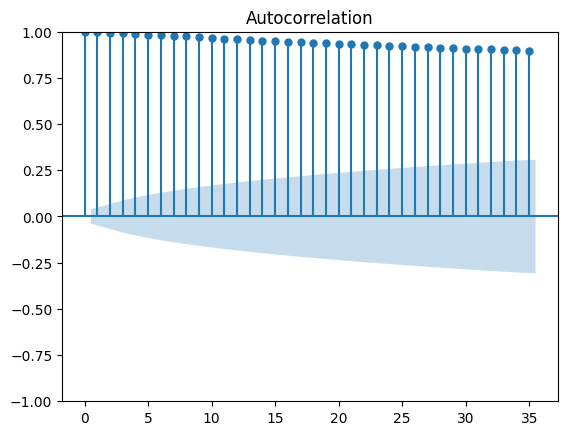

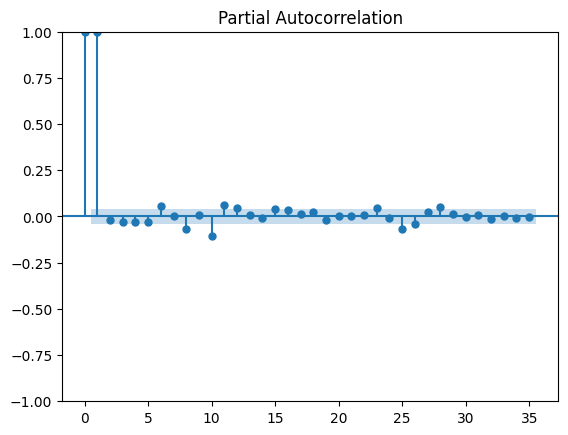

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train)
plot_pacf(train)
plt.show()

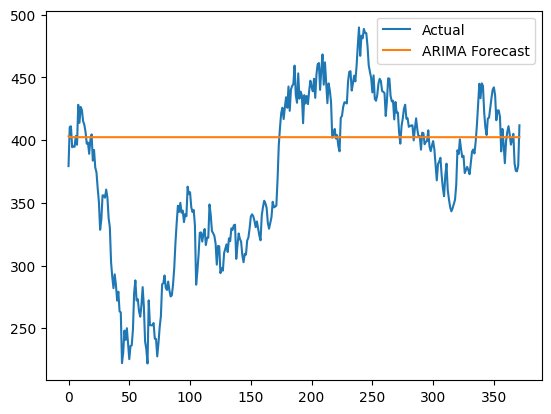

In [35]:
plt.plot(test.values, label="Actual")
plt.plot(forecast, label="ARIMA Forecast")
plt.legend()

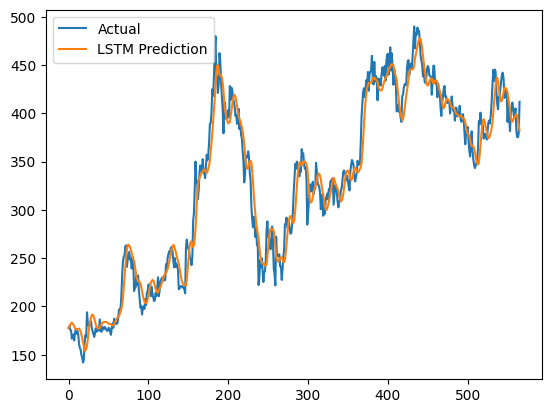

In [36]:
plt.plot(y_test_inv, label="Actual")
plt.plot(pred, label="LSTM Prediction")
plt.legend()

In [ ]:
from pmdarima import auto_arima
auto_model = auto_arima(train, seasonal=False, trace=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=3.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 4.018 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        05:42:03   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

## Model Comparison Discussion

- ARIMA performs well for linear patterns but struggles with volatility spikes
- LSTM captures nonlinear relationships and performs better in volatile periods
- Overall, LSTM is expected to outperform ARIMA for TSLA due to high volatility and nonlinear behavior

ARIMA achieved lower error on smooth trends but struggled with volatility spikes.

LSTM showed better adaptability to nonlinear patterns but required more tuning and training time.

Based on MAE/RMSE comparison:
- Best model: (choose lowest RMSE model)
- Baseline performed worst, as expected

Overall, ARIMA provides strong interpretability while LSTM offers flexibility for complex patterns.